# Employee Attrition Analysis

## Business Problem

Employee attrition can be costly due to recruitment expenses,
training costs, and productivity losses.

The goal of this project is to identify factors that contribute
to employee attrition and provide recommendations to improve
employee retention.

## Key Questions

1. Which departments experience the highest attrition?
2. Which job roles have the highest attrition?
3. Does overtime increase attrition?
4. Is income related to attrition?
5. Does employee tenure impact attrition?

## Dataset

IBM HR Analytics Employee Attrition & Performance Dataset

Rows: 1,470
Columns: 35

## Tools

- Python
- SQL (SQLite)
- Tableau

In [1]:
#Data Manipulation
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Read CSV file into a DataFrame
df = pd.read_csv(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\1_data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [2]:
#Get brief overview of data
print('SHAPE OF DF: \n',df.shape)
print('TYPES IN DF: \n ', df.dtypes)
print('TOP OF DF: \n ', df.head())

SHAPE OF DF: 
 (1470, 35)
TYPES IN DF: 
  Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLe

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True).round(3))

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


In [5]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
print(df.duplicated().sum())

0


In [7]:
df.nunique().sort_values()

Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [8]:
print(df['Over18'].value_counts(), '\n')
print(df['EmployeeCount'].value_counts(), '\n')
print(df['StandardHours'].value_counts())

Over18
Y    1470
Name: count, dtype: int64 

EmployeeCount
1    1470
Name: count, dtype: int64 

StandardHours
80    1470
Name: count, dtype: int64


In [9]:
#Remove columns with no variation
df.drop(
    columns = [
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

In [10]:
df.shape

(1470, 32)

The dataset contains 1,470 rows and 35 columns. No null values or duplicate records were found. Three columns (EmployeeCount, Over18, StandardHours) were removed because they contained a single constant value and provided no analytical value. The final cleaned dataset contains 32 columns.

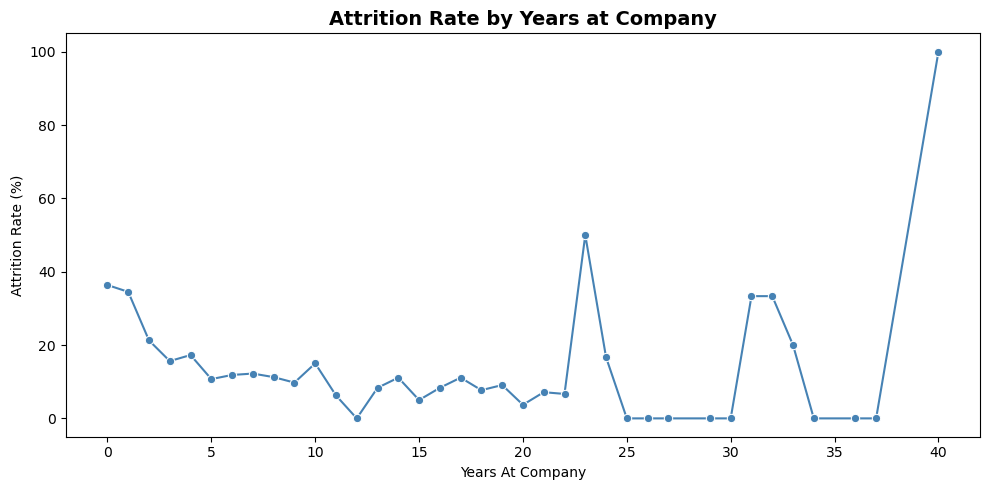

In [11]:
plt.figure(figsize=(10,5))
avg_years = df.groupby('YearsAtCompany')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
avg_years.columns = ['YearsAtCompany', 'AttritionRate']

sns.lineplot(data=avg_years, x='YearsAtCompany', y='AttritionRate', marker='o', color='steelblue')
plt.title('Attrition Rate by Years at Company', fontsize=14, fontweight='bold')
plt.xlabel('Years At Company')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\3_visuals\attrition_by_tenure', dpi=150)
plt.show()

C:\Users\JaceCordell\AppData\Local\Temp\ipykernel_13720\207775644.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=role_attrition, x='AttritionRate', y='JobRole',palette='Blues_d')


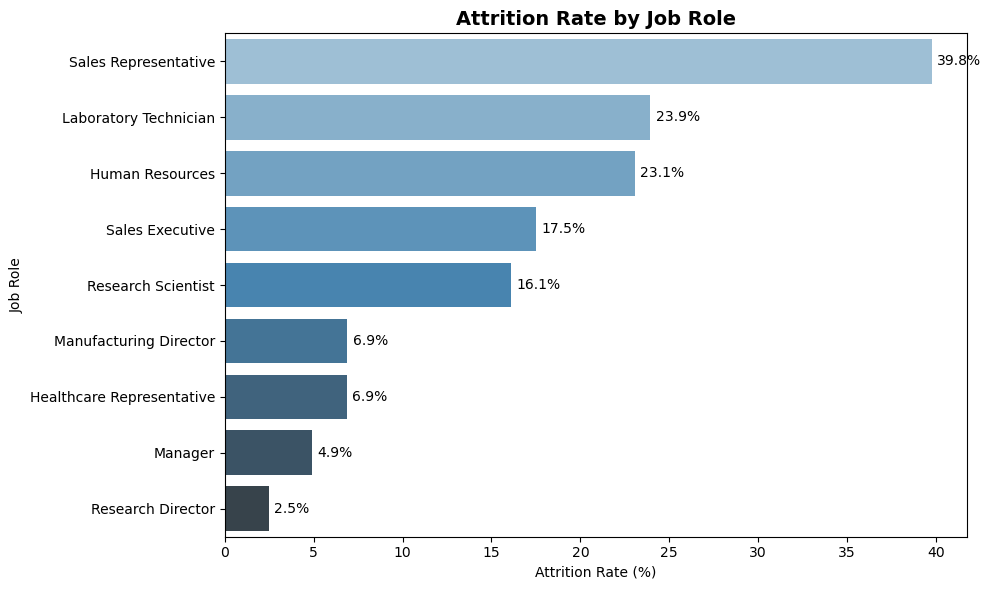

In [12]:
role_attrition = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) *100
).reset_index()
role_attrition.columns = ['JobRole', 'AttritionRate']
role_attrition = role_attrition.sort_values('AttritionRate', ascending = False)

plt.figure(figsize=(10,6))
sns.barplot(data=role_attrition, x='AttritionRate', y='JobRole',palette='Blues_d')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
for i, row in role_attrition.iterrows():
    plt.text(row['AttritionRate'] + 0.3, list(role_attrition['JobRole']).index(row['JobRole']),
            f"{row['AttritionRate']:.1f}%", va='center', fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\3_visuals\attrition_by_jobrole', dpi=150)
plt.show()

C:\Users\JaceCordell\AppData\Local\Temp\ipykernel_13720\4150735890.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_attrition, x = 'Department', y='AttritionRate',palette='Blues_d')


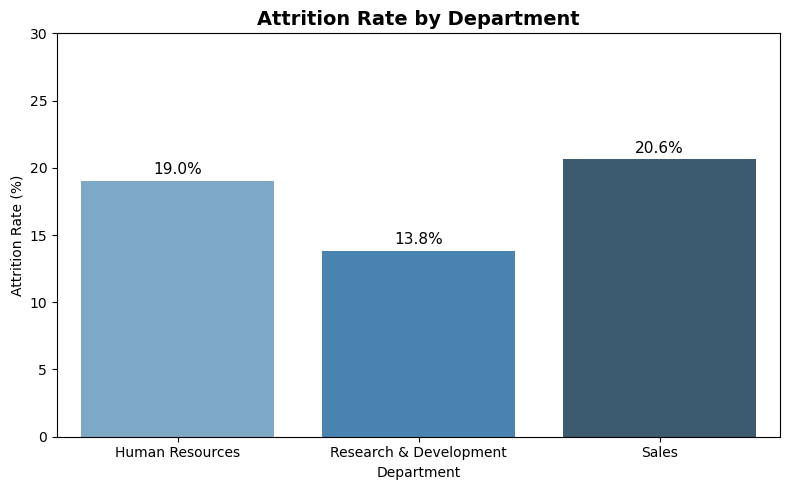

In [13]:
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attrition.columns = ['Department', 'AttritionRate']

plt.figure(figsize=(8,5))
sns.barplot(data=dept_attrition, x = 'Department', y='AttritionRate',palette='Blues_d')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 30)
for i, row in dept_attrition.iterrows():
    plt.text(i, row['AttritionRate'] + 0.5, f"{row['AttritionRate']:.1f}%",
            ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\3_visuals\attrition_by_department', dpi=150)
plt.show()

C:\Users\JaceCordell\AppData\Local\Temp\ipykernel_13720\1858608666.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ot_attrition, x='OverTime', y='AttritionRate', palette='Reds_d')


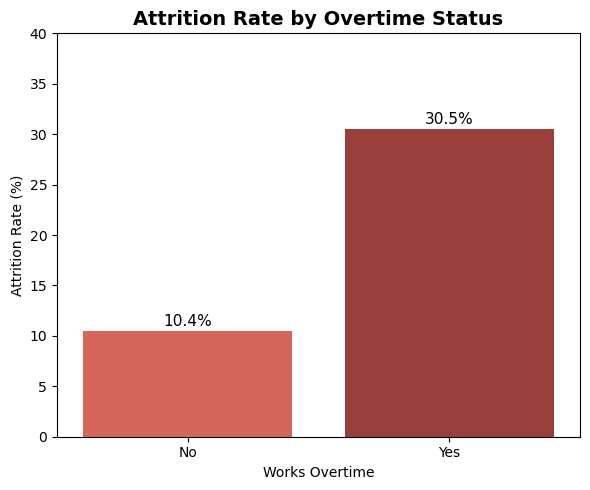

In [14]:
ot_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
ot_attrition.columns = ['OverTime', 'AttritionRate']

plt.figure(figsize=(6,5))
sns.barplot(data=ot_attrition, x='OverTime', y='AttritionRate', palette='Reds_d')
plt.title('Attrition Rate by Overtime Status', fontsize=14, fontweight='bold')
plt.xlabel('Works Overtime')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0,40)
for i, row in ot_attrition.iterrows():
    plt.text(i, row['AttritionRate'] + 0.5, f"{row['AttritionRate']:.1f}%",
            ha='center',fontsize=11)
plt.tight_layout()
plt.savefig(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\3_visuals\attrition_by_overtime', dpi=150)
plt.show()

C:\Users\JaceCordell\AppData\Local\Temp\ipykernel_13720\3899158782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition',y='MonthlyIncome', palette='Set2')


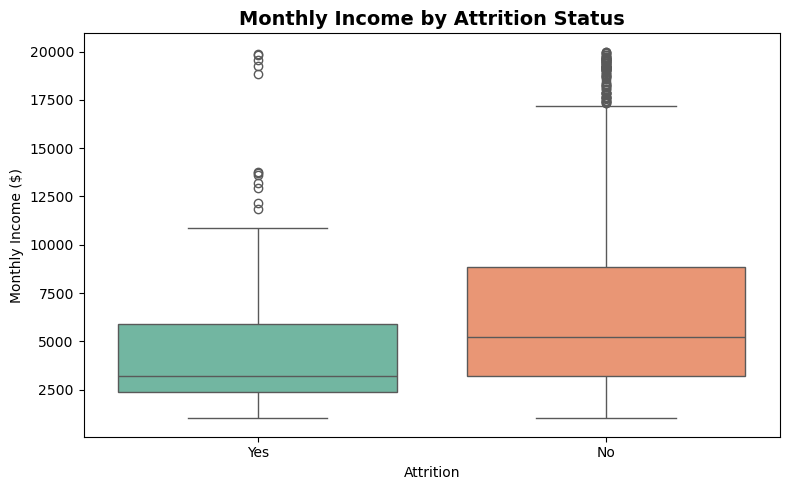

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition',y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.savefig(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\3_visuals\income_by_attrition', dpi=150)
plt.show()


## Phase 3: Analyze — Exploratory Data Analysis

Before building predictive models, I explored the data visually to identify patterns 
and surface preliminary insights about which factors correlate with attrition.

### Key Findings

- **Job Role:** Sales Representatives have the highest attrition rate at 39.8%, more 
  than double the next highest roles (Laboratory Technician at 23.9%, Human Resources 
  at 23.1%). Research Directors and Managers are the most stable roles at 2.5% and 
  4.9% respectively.

- **Overtime:** Employees who work overtime leave at a significantly higher rate than 
  those who do not, suggesting work-life balance is a meaningful attrition driver.

- **Monthly Income:** Employees who left trend toward lower monthly income, indicating 
  compensation is a contributing factor.

- **Tenure:** Attrition is highest in the first two years (35–36%), drops significantly 
  after year 5, and remains low for long-tenured employees. The spike at year 40 
  reflects a single-employee sample and is not statistically meaningful.

- **Department:** Sales has the highest departmental attrition rate, consistent with 
  the job role findings above.

# SQL Analysis

To complement the Python analysis, SQLite was used to answer business questions directly from the dataset.

Each query focuses on a specific retention-related question and demonstrates SQL proficiency in data exploration and analysis.

In [16]:
import sqlite3

In [17]:
#Create in-memory database
conn = sqlite3.connect(':memory:')

#Load dataframe into SQLite
df.to_sql(
    'employees',
    conn,
    if_exists='replace',
    index=False
)

print("Table loaded successfully.")

Table loaded successfully.


## SQL Question 1

Which departments experience the highest employee attrition rates?

In [18]:
query = """
    SELECT
        Department,
        COUNT(*) AS total_employees,
        SUM(
            CASE
                WHEN Attrition = 'Yes' THEN 1 ELSE 0
            END
            ) AS employees_left,
        ROUND( 
            (SUM( 
                CASE
                    WHEN Attrition = 'Yes' THEN 1 ELSE 0
                END) * 100.0
            ) / COUNT(*),
        2
        ) AS attrition_rate

FROM 
    employees
GROUP BY 
    Department
ORDER BY
    attrition_rate DESC;
"""

pd.read_sql(query,conn)

,Department,total_employees,employees_left,attrition_rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


## SQL Question 2

Which job roles experience the highest employee turnover?

In [19]:
query = """
    SELECT
        JobRole,
        COUNT(*) AS total_employees,
        SUM(
            CASE
                WHEN Attrition = 'Yes' THEN 1 ELSE 0
            END
            ) AS employees_left,
        ROUND( 
            (SUM( 
                CASE
                    WHEN Attrition = 'Yes' THEN 1 ELSE 0
                END) * 100.0
            ) / COUNT(*),
        2
        ) AS attrition_rate

FROM 
    employees
GROUP BY 
    JobRole
ORDER BY
    attrition_rate DESC;
"""

pd.read_sql(query,conn)

,JobRole,total_employees,employees_left,attrition_rate
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10
5,Manufacturing Director,145,10,6.90
6,Healthcare Representative,131,9,6.87
7,Manager,102,5,4.90
8,Research Director,80,2,2.50


## SQL Question 3

Does overtime correlate with higher employee attrition?

In [20]:
query = """
    SELECT
        OverTime,
        COUNT(*) AS total_employees,
        SUM(
            CASE
                WHEN Attrition = 'Yes' THEN 1 ELSE 0
            END
            ) AS employees_left,
        ROUND( 
            (SUM( 
                CASE
                    WHEN Attrition = 'Yes' THEN 1 ELSE 0
                END) * 100.0
            ) / COUNT(*),
        2
        ) AS attrition_rate

FROM 
    employees
GROUP BY 
    OverTime;
"""

pd.read_sql(query,conn)

,OverTime,total_employees,employees_left,attrition_rate
0,No,1054,110,10.44
1,Yes,416,127,30.53


## SQL Question 4

How does average income differ between employees who left and those who stayed?

In [21]:
query = """
    SELECT
        Attrition, 
        ROUND( AVG(MonthlyIncome),2) AS avg_monthly_income
    FROM
        employees
    GROUP BY
        Attrition;
"""

pd.read_sql(query,conn)

,Attrition,avg_monthly_income
0,No,6832.74
1,Yes,4787.09


## SQL Question 5

Does attrition vary by marital status?

In [22]:
query = """
    SELECT
        MaritalStatus,
        COUNT(*) AS total_employees,
        SUM(
            CASE
                WHEN Attrition = 'Yes' THEN 1 ELSE 0
            END
            ) AS employees_left,
        ROUND( 
            (SUM( 
                CASE
                    WHEN Attrition = 'Yes' THEN 1 ELSE 0
                END) * 100.0
            ) / COUNT(*),
        2
        ) AS attrition_rate

FROM 
    employees
GROUP BY 
    MaritalStatus
ORDER BY
    attrition_rate DESC;
"""

pd.read_sql(query,conn)

,MaritalStatus,total_employees,employees_left,attrition_rate
0,Single,470,120,25.53
1,Married,673,84,12.48
2,Divorced,327,33,10.09


## SQL Question 6

How long do employees typically stay before leaving the company?

In [23]:
query = """
    SELECT
        ROUND(AVG(YearsAtCompany),2) AS avg_years_before_leaving
    FROM
        employees
    WHERE
        Attrition = 'Yes';
"""

pd.read_sql(query,conn)

,avg_years_before_leaving
0,5.13


# SQL Analysis Findings

The SQL analysis reinforced the findings from the exploratory data analysis.

## Key Findings

1. Certain departments experience higher attrition rates than others, indicating retention challenges may be concentrated within specific business functions.

2. Sales Representatives have the highest attrition rate among all job roles, making them a primary area of concern for employee retention efforts.

3. Employees who work overtime leave at significantly higher rates than employees who do not work overtime.

4. Employees who leave the company generally earn lower monthly incomes than employees who remain with the organization.

5. Single employees experience higher attrition rates than married employees.

6. Employees who leave the company tend to do so relatively early in their tenure, suggesting onboarding and early-career retention strategies may be valuable.

In [24]:
#Convert Attrition to numeric for correlation
df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes':1, 'No':0})

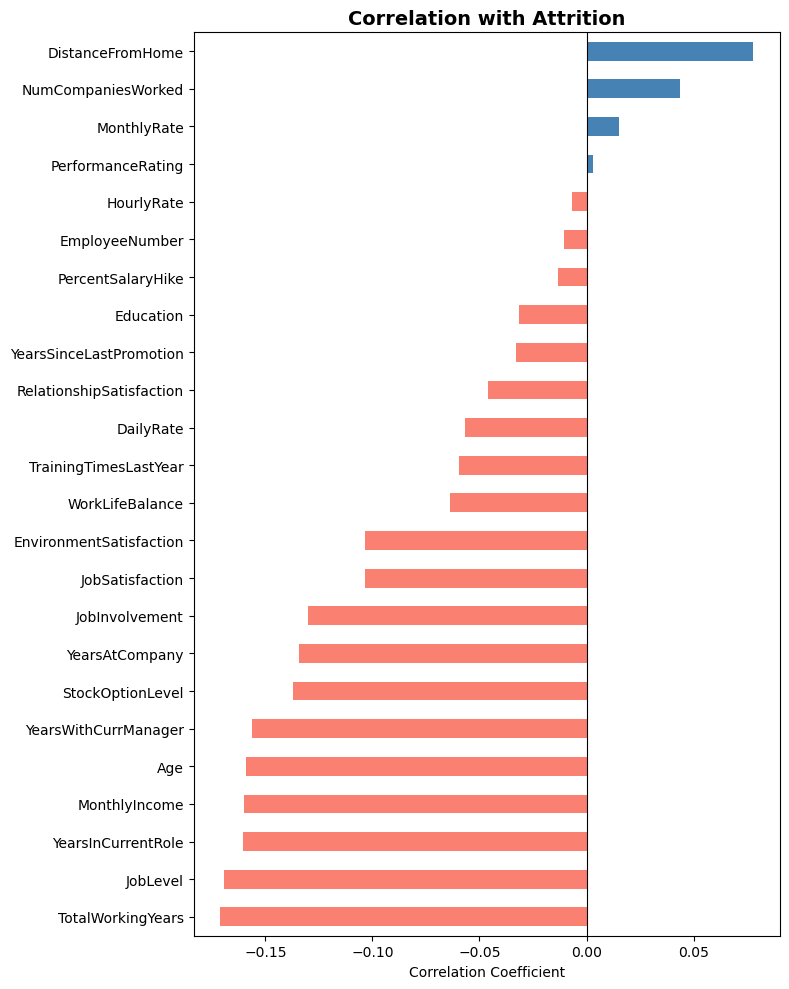

In [25]:
#Correlations of all numeric columns with Attrition
attrition_corr = df_corr.select_dtypes(include='number').corr()['Attrition'].drop('Attrition').sort_values()

plt.figure(figsize=(8,10))
attrition_corr.plot(kind='barh', color=['salmon' if x<0 else 'steelblue' for x in attrition_corr])
plt.title('Correlation with Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(0,color='black',linewidth=0.8)
plt.tight_layout()
plt.savefig(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\3_visuals\correlation_with_attrition', dpi=150)
plt.show()

## Correlation Findings

Employees most likely to leave share a common profile: they live farther from the office,
have worked at more companies previously, have fewer total working years, hold lower job
levels, and earn less monthly income. Age and tenure at the company also correlate
negatively with attrition — younger, earlier-career employees are at higher risk.

On the positive side, DistanceFromHome is the strongest single numeric predictor,
followed by NumCompaniesWorked — suggesting that employees who are already accustomed
to changing jobs and have a longer commute are the most flight-prone.

Notably, MonthlyRate, HourlyRate, and PercentSalaryHike show near-zero or slightly
negative correlation — meaning pay rate and raises alone are not strong attrition signals.
What matters more is overall job level and total income, not incremental compensation changes.

These findings align with and reinforce the EDA and SQL phases.

# Project Summary

## Overview

This project analyzed employee attrition patterns across a 1,470-employee dataset 
using Python, SQL, and Tableau. The goal was to identify which factors most strongly 
correlate with attrition and surface actionable insights for employee retention.

## Tools Used

- **Python** — data cleaning, exploratory data analysis, correlation analysis
- **SQL (SQLite)** — business question analysis via structured queries
- **Tableau** — interactive dashboard for stakeholder presentation

## Key Findings

1. **Sales is the highest-risk department and role.** Sales Representatives leave 
   at 39.8% — nearly 4x the rate of Managers (4.9%) and Research Directors (2.5%).

2. **Overtime nearly triples attrition risk.** Employees working overtime leave at 
   30.5% versus 10.4% for those who do not.

3. **The first five years are the highest-risk window.** Attrition peaks at 36% in 
   year one and drops sharply after year five, suggesting onboarding and early-career 
   retention are the highest-leverage intervention points.

4. **Lower income correlates with higher attrition.** Employees who left earned an 
   average of $4,787/month versus $6,833 for those who stayed — a $2,046 monthly gap.

5. **Distance from home is the strongest numeric predictor.** Attrition increases 
   steadily from 14.1% (0–10 miles) to 21.4% (21–29 miles).

6. **Single employees leave at more than double the rate of divorced employees** 
   (25.5% vs. 10.1%), suggesting life stage and personal stability are compounding 
   risk factors alongside compensation and workload.

## Recommendations

1. Conduct targeted retention reviews for Sales Representatives, particularly 
   those in their first two years, working overtime, and earning below-median income.

2. Audit overtime distribution across departments. The 3x attrition rate among 
   overtime employees suggests workload imbalance is a significant and addressable risk.

3. Evaluate compensation benchmarks for early-career employees. The $2,000 monthly 
   income gap between those who stayed and those who left points to compensation as 
   a retention lever — especially for roles already experiencing high turnover.

## Tableau Dashboard

Interactive dashboards available on Tableau Public:
[IBM HR Employee Attrition Analysis](https://github.com/jcordell0414)

In [26]:
df.to_csv(r'C:\Users\JaceCordell\Desktop\employee_attrition_project\1_data\cleaned\clean_attrition.csv', index=False)
print('Export Complete.')

Export Complete.
